# Step 1: Setting Up Your Environment

Welcome to the tutorial on utilizing our custom package for dataset acquisition and training a ResNet model. This guide is designed to help you seamlessly set up your environment, ensuring you have all the necessary tools and packages installed to begin your journey in deep learning with our specialized dataset. Whether you are an experienced data scientist or just starting out, this step-by-step tutorial will walk you through the process of preparing your workspace for optimal performance and ease of use. Let's get started on setting up your environment to unlock the full potential of our resources.



In [ ]:
# setting up the other dependencies
!pip install torch torchvision Pillow numpy tqdm requests matplotlib

In [ ]:
# instaling our package
!pip install LymphoMNIST

# Step 2: Loading the Dataset

This section guides you through loading the dataset with the `LymphoMNIST` package, designed for ResNet model training. We'll cover importing essential libraries and applying necessary transformations using `torchvision` to resize images and convert them to tensors for neural network compatibility.

We initialize the `LymphoMNIST` dataset, detailing parameters like the root directory, data type (training), and transformations. Aimed at advancing medical imaging, this dataset focuses on lymphocyte segmentation and classification. Specifying `num_classes` is optional; by default, or if no parameter is passed, three classes (`B`, `T4`, `T8` cells) will be loaded. For `num_classes=3`, it loads these three classes, and for `num_classes=2`, it loads `B` and `T` cells by merging `T4` and `T8` into same class.

The provided code snippet sets up a data loader, optimizing batch size and class selection for efficient training. With the dataset properly formatted and loaded, you're now set for the model training phase.


In [1]:
# Lets import the packages
import torch
from torchvision import transforms
from LymphoMNIST.LymphoMNIST import LymphoMNIST

# check LymphoMNIST virsion
import LymphoMNIST as info
print(f"LymphoMNIST v{info.__version__} @ {info.HOMEPAGE}")

LymphoMNIST v1.0 @ https://github.com/Khayrulbuet13/LymphoMNIST


In [5]:
# Define transformations
transform = transforms.Compose([
    transforms.Resize((224, 224)),  # Resize images to fit ResNet18 input
    transforms.ToTensor(),
])

# Initialize dataset
test_dataset = LymphoMNIST(root='./data', train=True, download=True, transform=transform, num_classes=3)
data_loader = torch.utils.data.DataLoader(test_dataset, batch_size=64, shuffle=True, num_workers=2)


./data/LymphoMNIST/raw/idx_files.zip: 100%|██████████| 328M/328M [00:08<00:00, 39.5MiB/s]    


Dataset downloaded and extracted successfully.


# Step 3: Data Manipulation and Visualization

Data visualization is a crucial step in understanding and interpreting the characteristics of your dataset. This section introduces a method to manipulate and visually inspect the images within the `LymphoMNIST` dataset. Through the use of `matplotlib`, we provide a practical approach to plot a grid of images directly from the data loader, allowing for a quick and informative overview of the dataset's content.

The provided function, `plot_dl`, dynamically generates a square grid of images, up to `n` by `n`, showcasing random samples from the dataset. This visual inspection tool is enhanced with optional label mapping, offering clear identification of each image's class based on the dataset's `classes` attribute. Whether dealing with color or grayscale images, the function adjusts to display each sample appropriately, ensuring a comprehensive view of the dataset's diversity.

This visualization capability is essential for initial data exploration, facilitating a deeper understanding of the dataset structure and composition, crucial for effective model training and evaluation.


In [3]:
# Print the shape of the batch in the format [batch_size, channels, height, width]
images, labels = next(iter(data_loader))
print(f"Shape of the dataset batch: {images.shape}")

# number of batches
print(f"Number of batches: {len(data_loader)}")

Shape of the dataset batch: torch.Size([64, 1, 224, 224])
Number of batches: 1000


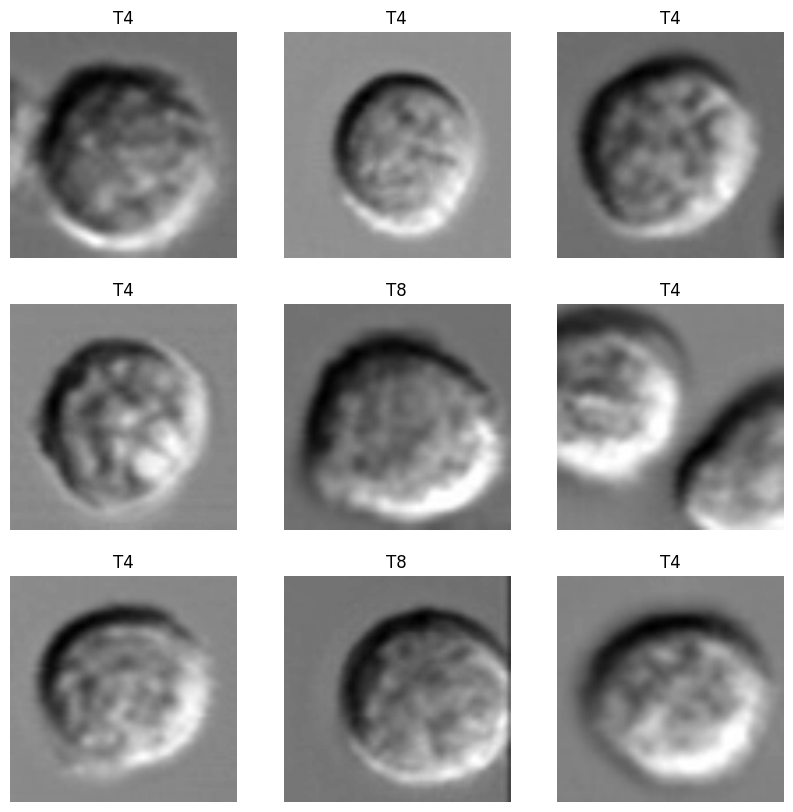

In [6]:
import matplotlib.pyplot as plt
import torch

def plot_dl(dl, labels_map=None, n=3):
    figure = plt.figure(figsize=(10, 10))  # Set figure size for better visibility
    cols, rows = n, n
    
    # Ensure we get n*n images; if the dataloader doesn't have enough, reduce n accordingly
    total_images = min(len(dl.dataset), n*n)
    cols, rows = n, min(total_images, n)
    
    for i in range(1, cols * rows + 1):
        # Directly accessing the dataset for random samples
        sample_idx = torch.randint(len(dl.dataset), size=(1,)).item()
        img, label = dl.dataset[sample_idx]
        
        figure.add_subplot(rows, cols, i)
        if labels_map:
            plt.title(labels_map[label.item()])
        else:
            plt.title(label.item())
        plt.axis("off")
        if img.shape[0] == 3:  # If it's a color image
            plt.imshow(img.permute(1, 2, 0))  # Convert from CxHxW to HxWxC
        else:  # If it's a grayscale image
            plt.imshow(img.squeeze(), cmap="gray")  # Remove channel dim if it's present
    
    plt.show()

# Generate a label map from the dataset's classes attribute
labels_map = {i: cls for i, cls in enumerate(test_dataset.classes)}

plot_dl(data_loader,labels_map, n=3)


# Conclusion

Hey, you've made it to the end of our tutorial! By now, you've got everything set up, a solid grasp on how to load and work with the `LymphoMNIST` dataset, and the know-how to visualize the data. 

Throughout this guide, we tackled the basics from setting up your environment, to getting the dataset ready with the right transformations, and even playing around with data visualization. 

Thanks for sticking with me through this tutorial. Can't wait to see the cool stuff you'll do with these dataset in your projects!
